# GrowthParameterEstimation quick test
Step-by-step joint fits for 20k + 30k with shared K and optional shared r.
Day 0 is forced to 67 (20k) and 100 (30k).

In [15]:
using Pkg
Pkg.add(["GrowthParameterEstimation", "CSV", "DataFrames", "OrdinaryDiffEq", "Plots", "BlackBoxOptim"])
using GrowthParameterEstimation, CSV, DataFrames, OrdinaryDiffEq, Plots, Statistics, BlackBoxOptim

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\elbak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\elbak\.julia\environments\v1.12\Manifest.toml`


## Step 1: Load monoculture day-averaged data
This enforces day 0 and sets $u_0$ to 67 (20k) or 100 (30k).

In [16]:
base_dir = raw"c:\Users\elbak\Desktop\ForgeLabs\CancerGrowthDynamics\Processed_Datasets\Untreated MonoCulture"
u0_map = Dict("20k" => 67.0, "30k" => 100.0)

function load_day_averages(density::String, variant::String)
    file_name = variant == "naive" ? "A2780Naive_day_averages.csv" : "A2780cis_day_averages.csv"
    data_path = joinpath(base_dir, density, "Averages", file_name)
    df = CSV.read(data_path, DataFrame)
    x = Float64.(df[!, "Day"])
    y = Float64.(df[!, "Mean Cells"])
    u0 = u0_map[density]
    if x[1] == 0.0
        y[1] = u0
    else
        x = vcat(0.0, x)
        y = vcat(u0, y)
    end
    return x, y, u0
end

function load_both_densities(variant::String)
    x20, y20, u020 = load_day_averages("20k", variant)
    x30, y30, u030 = load_day_averages("30k", variant)
    return (x20, y20, u020), (x30, y30, u030)
end

load_both_densities (generic function with 1 method)

## Step 2: Define models and joint-fit helpers
Shared K across 20k/30k. Compare shared r (M1) vs separate r (M2).

In [17]:
epsu(x) = max(x, 1e-9)

function logistic_joint_m1!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * (1 - u[1] / K)
    du[2] = r * u[2] * (1 - u[2] / K)
end

function logistic_joint_m2!(du, u, p, t)
    r20, r30, K = p
    du[1] = r20 * u[1] * (1 - u[1] / K)
    du[2] = r30 * u[2] * (1 - u[2] / K)
end

function gompertz_joint_m1!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * log(K / epsu(u[1]))
    du[2] = r * u[2] * log(K / epsu(u[2]))
end

function gompertz_joint_m2!(du, u, p, t)
    r20, r30, K = p
    du[1] = r20 * u[1] * log(K / epsu(u[1]))
    du[2] = r30 * u[2] * log(K / epsu(u[2]))
end

function generalized_logistic_joint_m1!(du, u, p, t)
    r, K, nu = p
    du[1] = r * u[1] * (1 - (epsu(u[1]) / K)^nu)
    du[2] = r * u[2] * (1 - (epsu(u[2]) / K)^nu)
end

function generalized_logistic_joint_m2!(du, u, p, t)
    r20, r30, K, nu = p
    du[1] = r20 * u[1] * (1 - (epsu(u[1]) / K)^nu)
    du[2] = r30 * u[2] * (1 - (epsu(u[2]) / K)^nu)
end

function exponential_joint_m1!(du, u, p, t)
    r = p[1]
    du[1] = r * u[1]
    du[2] = r * u[2]
end

function exponential_joint_m2!(du, u, p, t)
    r20, r30 = p
    du[1] = r20 * u[1]
    du[2] = r30 * u[2]
end

function bic_from_sse(sse, n, k)
    return n * log(sse / n) + k * log(n)
end

function fit_joint(x20, y20, u020, x30, y30, u030; model=:logistic, shared_r=true)
    k_guess = max(maximum(y20), maximum(y30)) * 1.2
    if model == :logistic && shared_r
        f! = logistic_joint_m1!; p0 = [0.2, k_guess]; bounds = [(0.0, 2.0), (100.0, 40000.0)]
    elseif model == :logistic
        f! = logistic_joint_m2!; p0 = [0.2, 0.2, k_guess]; bounds = [(0.0, 2.0), (0.0, 2.0), (100.0, 40000.0)]
    elseif model == :gompertz && shared_r
        f! = gompertz_joint_m1!; p0 = [0.2, k_guess]; bounds = [(0.0, 2.0), (100.0, 40000.0)]
    elseif model == :gompertz
        f! = gompertz_joint_m2!; p0 = [0.2, 0.2, k_guess]; bounds = [(0.0, 2.0), (0.0, 2.0), (100.0, 40000.0)]
    elseif model == :genlogistic && shared_r
        f! = generalized_logistic_joint_m1!; p0 = [0.2, k_guess, 1.0]; bounds = [(0.0, 2.0), (100.0, 40000.0), (0.1, 5.0)]
    elseif model == :genlogistic
        f! = generalized_logistic_joint_m2!; p0 = [0.2, 0.2, k_guess, 1.0]; bounds = [(0.0, 2.0), (0.0, 2.0), (100.0, 40000.0), (0.1, 5.0)]
    elseif model == :exponential && shared_r
        f! = exponential_joint_m1!; p0 = [0.2]; bounds = [(0.0, 2.0)]
    elseif model == :exponential
        f! = exponential_joint_m2!; p0 = [0.2, 0.2]; bounds = [(0.0, 2.0), (0.0, 2.0)]
    else
        error("Unknown model: ", model)
    end

    tspan = (min(minimum(x20), minimum(x30)), max(maximum(x20), maximum(x30)))
    prob = ODEProblem(f!, [u020, u030], tspan, p0)
    save_times = sort(unique(vcat(x20, x30)))

    loss = function(p)
        sol = solve(remake(prob, p=p), Tsit5(); saveat=save_times)
        pred20 = [sol(t)[1] for t in x20]
        pred30 = [sol(t)[2] for t in x30]
        return sum(abs2.(y20 .- pred20)) + sum(abs2.(y30 .- pred30))
    end

    res = bboptimize(loss; SearchRange=bounds, MaxTime=20.0, TraceMode=:silent)
    p_best = best_candidate(res)
    sol = solve(remake(prob, p=p_best), Tsit5(); saveat=save_times)
    sse = loss(p_best)
    n = length(x20) + length(x30)
    bic = bic_from_sse(sse, n, length(p_best))
    return p_best, sol, sse, bic
end

function plot_joint(x20, y20, x30, y30, sol; title_str="")
    p = scatter(x20, y20; label="20k data", markersize=4, xlabel="Day", ylabel="Cells", title=title_str)
    scatter!(p, x30, y30; label="30k data", markersize=4)
    tgrid = sol.t
    pred20 = getindex.(sol.u, 1)
    pred30 = getindex.(sol.u, 2)
    plot!(p, tgrid, pred20; label="20k fit", linewidth=2)
    plot!(p, tgrid, pred30; label="30k fit", linewidth=2)
    display(p)
end

function run_joint_model(variant::String, model::Symbol)
    (x20, y20, u020), (x30, y30, u030) = load_both_densities(variant)
    p1, sol1, sse1, bic1 = fit_joint(x20, y20, u020, x30, y30, u030; model=model, shared_r=true)
    p2, sol2, sse2, bic2 = fit_joint(x20, y20, u020, x30, y30, u030; model=model, shared_r=false)
    best = bic2 < bic1 ? ("M2 (separate r)", p2, sol2, bic2) : ("M1 (shared r)", p1, sol1, bic1)
    title_str = string(uppercase(string(model))) * " - " * variant * " - " * best[1]
    plot_joint(x20, y20, x30, y30, best[3]; title_str=title_str)
    return (m1_bic=bic1, m2_bic=bic2, chosen=best[1], params=best[2])
end

run_joint_suite (generic function with 1 method)

## Step 3: Run joint fits
For each model: compare M1 (shared r) vs M2 (separate r), keep the lower BIC.

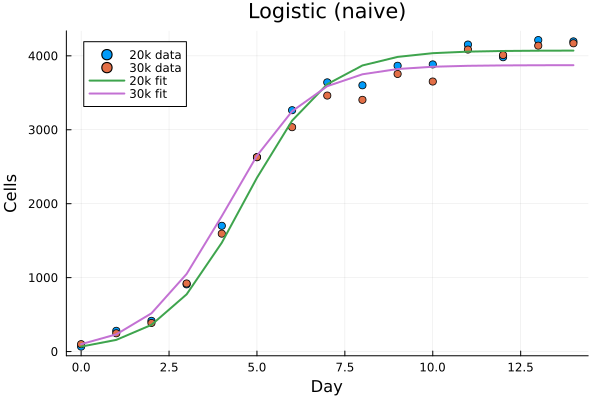

DomainError: DomainError with -1.0502878217026936:
Exponentiation yielding a complex result requires a complex argument.
Replace x^y with (x+0im)^y, Complex(x)^y, or similar.

In [18]:
models = [:logistic, :genlogistic, :gompertz, :exponential]

for m in models
    println("Naive - ", m, ": ", run_joint_model("naive", m))
    println("Resistant - ", m, ": ", run_joint_model("resistant", m))
end